# Decision Trees:
A decision tree can be viewed as a massive upside-down tree, from the top, new data is fed into the tree and put through a if/else condition, each condition block is a branch, each branch might lead into another branch on the tree, which contains more if/else condition blocks, in training, this tree keeps growing with more branches until it gets to a point where the model cannot find any more if/else condition blocks, in which case the tree grows a leaf. 

New data that is fed through this tree quickly gets put against each if/else condition, going through a particular branch in the tree until it hits a leaf. Once the new data hits a leaf in the tree, the data can be classified in the label on the leaf.

Decision trees can be used for both classification and regression. Classification trees run new data through nested if/else conditions based on feature thresholds, and the leaf nodes predict a class label for the new data. While regression trees also use nested if/else conditions, however, the leaf node predicts a numerical value, which is usually the average of the training samples that happen to also fall within the same region.


# Support Vector Machines (SVMs):
SVMs draw a hyperplane in the multidimensional space that represents the data. The main goal for the SVM is to draw a hyperplane that can clearly classify the data by positioning the hyperplane to maximize the distance from the closest points in each class. The bigger the gap between these hyperplanes, the less likely the small fluctuations in the data are to have an impact on the outcome. Improving accuracy and generalization. 


Data that's non-linear can be solved by increasing the dimensions of the space until a linear hyperplane works; however, doing so will drastically increase the computational complexity of the model. To fix this, SVM finds the dot products for every pair of points by using the kernel function. The model can then create a kernel matrix with these dot products and find the relationship of each pair to create a relationship between the points as if they were in a higher dimension. This allows the model to then fit a hyperplane in the higher dimension without actually computing a higher dimension.

In training, there are two ways to handle multi-class classification: One-Vs-Rest (OvR) or One-vs-One (OvO). OvR classifies new data by checking if the new data fits in a class or not; it then does this for each class in the model. The class with the highest confidence (furthest from its hyperplane) is the class the new data is predicted to be. 

OvO classifies new data by first finding all possible pairs of classes. Then, for every pair, the model checks which class the new data fit within the best. It then checks the data again with every possible pair in the model, then classifies the new data based on which class has been voted the most. OvR models are much simpler as there are fewer checks; however, OvO can be more precise if the classes happen to overlap.


# Breast Cancer Detection/Prediction:

The breast cancer dataset is a supervised learning dataset consisting of either malignant (cancerous) or benign (non-cancerous) tumors in the breasts. This dataset consists of 569 samples, each consisting of 30 features such as the mean radius, smoothness, and mean texture.

In [67]:
from sklearn.datasets import load_breast_cancer

breast_cancer_dataset = load_breast_cancer()
breast_cancer_dataset.keys()


print("terget names:", breast_cancer_dataset.target_names)
print("data shape:", breast_cancer_dataset.data.shape)
print("feature names:", breast_cancer_dataset.feature_names)
print("number of samples:", breast_cancer_dataset.target.shape[0])
breast_cancer_dataset.target

X = breast_cancer_dataset['data']      # features (numerical measurements)
y = breast_cancer_dataset['target']    # labels (0 = malignant, 1 = benign)



terget names: ['malignant' 'benign']
data shape: (569, 30)
feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
number of samples: 569


In [68]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [69]:
%%capture
from sklearn.svm import SVC

model = SVC()
model.fit(X_train, y_train)



In [70]:
%%capture
from sklearn.model_selection import GridSearchCV

# Define the model
model = SVC()

# Specify the hyperparameters
param_grid = [
    {'C': [0.5, 0.1, 1, 5, 10], 
     'kernel': ['linear'], 
     'class_weight': ['balanced']},
    {'C': [0.5, 0.1, 1, 5, 10],
     'gamma': [0.0001, 0.001, 0.01, 0.1, 0.005, 0.05, 0.5], 
     'kernel': ['rbf'],
     'class_weight': ['balanced']},
     {'C': [0.5, 0.1, 1, 5, 10],
     'kernel': ['poly'],
     'degree': [2, 3, 4],
     'coef0': [0.0, 0.1],
     'class_weight': ['balanced']},
     {'C': [0.5, 0.1, 1, 5, 10],
     'gamma': [0.0001, 0.001, 0.01, 0.1, 0.005, 0.05, 0.5], 
     'kernel': ['sigmoid'],
     'coef0': [0.0, 0.1],
     'class_weight': ['balanced']}]


# Run Grid Search on the specified hyperparameters
grs = GridSearchCV(model, param_grid)
grs.fit(X_train, y_train)

The model parameters are learned during training and include things such as support vectors and associated weights. These values define the hyperplane that separates the classes in the model. The hyperparameters are set before training, and control how the model creates the hyperplane. 

**C:** Controls the generalization, or how wide the margin is between hyperplanes. Small C values allow wider margins but more misclassifications, while larger C values reduce error but might overfit.

**kernel:** Controls what type of hyperplane, either RBF or Linear

**gamma:** For the RBF kernel, it controls how smooth the hyperplane is. Large gamma values create more complex/wiggly hyperplanes, while smaller gamma values create a smoother hyperplane.

**class_weight:** Adds bias towards a particular class, which could help imbalanced datasets.

These values could be optimised using a grid search, which iterates over each hyperparameter and finds the best estimator.

The relevant kernel functions for SVM include: linear, polynomial, RBF, and sigmoid. Each kernel computes the relationship between data pairs differently, effectively creating hyperplanes. For this implementation, a linear kernel was selected. This decision was made from the output of the grid search optimization. 

In the code ```SVC(C=1.0, cache_size=200, class_weight=None, coef0.0.0, decision_function_shape='ovr', degree=3, gamma='auto', kernel='rbf', max_iter=-1, probability=False, random_state=None, shrinking=True, tol=0.001, verbose=False)```

**C:** Controls the generalization, or how wide the margin is between hyperplanes. A C value of 1 is pretty moderate, perfectly in the middle

**decision_function_shape:** Depicts how the SVM handles muti-class classification, in this scenario, One-vs-Rest was chosen.

**degree:** This is used for the poly kernel, but it defines what polynomial will be used for classification, in this case a cubic was chosen.

**gamma:** Controls the influence of a signle traning point when shaping a decision boundary, the larger the gammer, the more wiggly the boundary becomes. In this case, the model choses it

**kernel:** Defines what relationship type will be used when finding the dot-product of the data points. In this case, rbf was chosen which is a good all rounder kernel.

In [71]:
model = grs.best_estimator_
svm_y_pred = model.predict(X_test)


Decision Tree
Accuracy:0.956140350877193 Precision:0.9569049312470365 Recall:0.956140350877193 F1:0.9558014271241044 MSE:0.043859649122807015
              precision    recall  f1-score   support

   malignant       0.97      0.91      0.94        43
      benign       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


SVM
Accuracy:0.9473684210526315 Precision:0.9484193575726757 Recall:0.9473684210526315 F1:0.9475905673274094 MSE:0.05263157894736842
              precision    recall  f1-score   support

   malignant       0.91      0.95      0.93        43
      benign       0.97      0.94      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.95      0.94       114
weighted avg       0.95      0.95      0.95       114



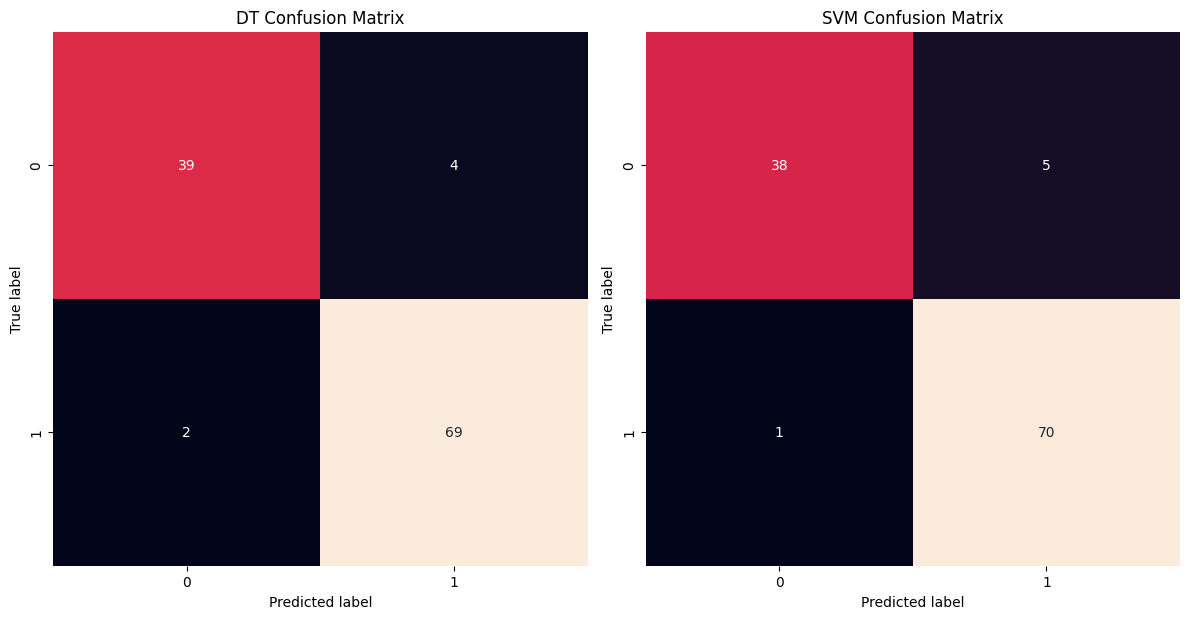

In [72]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from matplotlib import pyplot as plt
import seaborn as sns

model = DecisionTreeClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

grs = GridSearchCV(model, param_grid={'criterion': ['gini', 'entropy'], 'max_depth': range(1,10)}, cv = 5)
grs.fit(X_train, y_train)
model = grs.best_estimator_
y_pred = model.predict(X_test)

modes = ["Decision Tree", "SVM"]
for name in models:
    if name == "SVM" : y_pred = svm_y_pred
    print(f"\n{name}\nAccuracy:{metrics.accuracy_score(y_test,y_pred)} "
          f"Precision:{metrics.precision_score(y_test,y_pred,average='weighted')} "
          f"Recall:{metrics.recall_score(y_test,y_pred,average='weighted')} "
          f"F1:{metrics.f1_score(y_test,y_pred,average='weighted')} "
          f"MSE:{metrics.mean_squared_error(y_test,y_pred)}")
    print(metrics.classification_report(y_test, y_pred, target_names=breast_cancer_dataset.target_names))
    conf_matrices[name] = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
sns.heatmap(con_matrix, square=True, annot=True, fmt='d', cbar=False, ax=axes[0])
axes[0].set_xlabel('Predicted label')
axes[0].set_ylabel('True label')
axes[0].set_title('DT Confusion Matrix')
sns.heatmap(svm_con_matrix, square=True, annot=True, fmt='d', cbar=False, ax=axes[1])
axes[1].set_xlabel('Predicted label')
axes[1].set_ylabel('True label')
axes[1].set_title('SVM Confusion Matrix')

plt.tight_layout()
plt.show()

Both models performed well given the dataset. They both had good accuracy, with the decision tree being slightly more accurate. The decision tree performed well in avoiding false positives, but not as effectively as the SVM. If the model was designed for medical diagnosis, SVM would be a better fit for this use case as it's less likely to have false negatives. However, a Decision tree is better at preventing unnecessary follow-ups as it has a slightly higher precision.